In [1]:
import os
import zipfile
import requests
import pyreadstat


In [2]:
pip install pyreadstat


DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621
Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 514.8/514.8 kB 4.5 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of pyreadstat to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.2/510.2 kB 9.5 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 618.3/618.3 kB 8.2 M

In [3]:
pwd

'/Users/honganh/Desktop/job_visualization'

In [8]:
COLS = [
    "CNT",         # country
    "ST004D01T",   # gender
    "OCOD3",       # aspired occupation, ISCO-coded (the "what they want to be")
    "BSMJ",        # expected occupational status (ISEI score)
    "ESCS",        # socioeconomic status index
    "W_FSTUWT",    # final student weight (use for any aggregate estimate)
    "PV1MATH",     # first plausible value, math (achievement, optional)
    "PV1READ",     # first plausible value, reading
    "PV1SCIE",     # first plausible value, science
]
def extract(sav_path):
    print("Reading selected columns (this reads only what we need)...")
    df, meta = pyreadstat.read_sav(sav_path, usecols=COLS)

    labels = meta.variable_value_labels
    if "ST004D01T" in labels:
        df["gender"] = df["ST004D01T"].map(labels["ST004D01T"])
    if "OCOD3" in labels:
        df["occupation"] = df["OCOD3"].map(labels["OCOD3"])

    df.to_csv("2022.csv", index=False)
    print(df[["CNT", "gender", "occupation", "BSMJ"]].head())

In [9]:
extract("CY08MSP_STU_QQQ.SAV")

Reading selected columns (this reads only what we need)...
   CNT  gender       occupation  BSMJ
0  ALB  Female      No response   NaN
1  ALB    Male      No response   NaN
2  ALB    Male      No response   NaN
3  ALB  Female  Medical doctors  88.7
4  ALB  Female  Medical doctors  88.7


In [10]:
# what's the top 10 most popular occupations (in general, among the female and male)
# only the us


In [12]:
import pandas as pd


In [13]:
df = pd.read_csv("2022.csv")
df

,CNT,ST004D01T,OCOD3,BSMJ,ESCS,W_FSTUWT,PV1MATH,PV1READ,PV1SCIE,gender,occupation
0,ALB,1.0,9999,NaN,1.1112,3.15874,179.583,247.571,335.468,Female,No response
1,ALB,2.0,9999,NaN,-3.0507,4.34524,308.247,258.472,315.021,Male,No response
2,ALB,2.0,9999,NaN,-0.1867,7.83860,267.514,284.670,358.675,Male,No response
3,ALB,1.0,221,88.70,-3.2198,8.49148,272.649,321.547,214.823,Female,Medical doctors
4,ALB,1.0,221,88.70,-1.0548,3.70957,435.473,464.366,434.997,Female,Medical doctors
...,...,...,...,...,...,...,...,...,...,...,...
613739,UZB,1.0,221,88.70,-2.7487,69.40366,300.530,315.903,265.316,Female,Medical doctors
613740,UZB,2.0,9999,NaN,-0.2024,63.18910,265.080,278.035,294.882,Male,No response
613741,UZB,2.0,121,72.24,-2.0506,65.47339,420.221,310.081,392.258,Male,Business services and administration managers
613742,UZB,1.0,9999,NaN,-0.1290,66.15595,343.129,388.350,376.514,Female,No response


In [14]:
base = df.dropna(subset=["occupation", "gender", "BSMJ"]).copy()
base

,CNT,ST004D01T,OCOD3,BSMJ,ESCS,W_FSTUWT,PV1MATH,PV1READ,PV1SCIE,gender,occupation
3,ALB,1.0,221,88.70,-3.2198,8.49148,272.649,321.547,214.823,Female,Medical doctors
4,ALB,1.0,221,88.70,-1.0548,3.70957,435.473,464.366,434.997,Female,Medical doctors
8,ALB,1.0,2261,88.31,-1.1697,2.91870,355.148,429.286,360.621,Female,Dentists
10,ALB,2.0,122,73.71,-1.9799,3.41727,424.584,381.250,346.282,Male,"Sales, marketing and development managers"
13,ALB,2.0,3431,50.15,-2.5828,7.42217,326.677,285.698,326.622,Male,Photographers
...,...,...,...,...,...,...,...,...,...,...,...
613732,UZB,2.0,261,85.13,-0.5457,63.93175,405.577,328.633,400.828,Male,Legal professionals
613734,UZB,1.0,221,88.70,-1.5660,77.07738,356.776,273.553,280.862,Female,Medical doctors
613735,UZB,1.0,23,75.54,1.2682,63.12521,343.791,394.960,310.734,Female,Teaching professionals
613739,UZB,1.0,221,88.70,-2.7487,69.40366,300.530,315.903,265.316,Female,Medical doctors


In [15]:
usa_data = base[base["CNT"] == "USA"]
usa_data

,CNT,ST004D01T,OCOD3,BSMJ,ESCS,W_FSTUWT,PV1MATH,PV1READ,PV1SCIE,gender,occupation
595281,USA,2.0,2211,88.70,1.2582,485.2478,575.451,621.204,674.870,Male,Generalist medical practitioners
595283,USA,2.0,1120,70.34,1.3463,588.8771,680.277,714.523,716.256,Male,Managing directors and chief executives
595284,USA,1.0,2635,70.50,-1.3108,939.5268,461.899,508.940,510.311,Female,Social work and counselling professionals
595285,USA,1.0,2131,80.46,-0.9745,944.3411,501.214,597.437,582.918,Female,"Biologists, botanists, zoologists and related ..."
595288,USA,1.0,2634,85.85,0.7473,557.7143,443.956,562.822,501.518,Female,Psychologists
...,...,...,...,...,...,...,...,...,...,...,...
599826,USA,2.0,2411,76.65,0.0426,611.7240,481.461,541.170,528.497,Male,Accountants
599827,USA,1.0,2634,85.85,-0.0857,901.4194,481.033,565.863,565.852,Female,Psychologists
599828,USA,1.0,5141,31.08,0.5405,882.8742,568.395,652.657,634.702,Female,Hairdressers
599829,USA,1.0,3112,59.35,0.8619,815.8547,591.859,628.219,600.934,Female,Civil engineering technicians


In [16]:
girls = usa_data[usa_data["gender"]=="Female"]
boys = usa_data[usa_data["gender"]=="Male"]

In [17]:
girls

,CNT,ST004D01T,OCOD3,BSMJ,ESCS,W_FSTUWT,PV1MATH,PV1READ,PV1SCIE,gender,occupation
595284,USA,1.0,2635,70.50,-1.3108,939.5268,461.899,508.940,510.311,Female,Social work and counselling professionals
595285,USA,1.0,2131,80.46,-0.9745,944.3411,501.214,597.437,582.918,Female,"Biologists, botanists, zoologists and related ..."
595288,USA,1.0,2634,85.85,0.7473,557.7143,443.956,562.822,501.518,Female,Psychologists
595289,USA,1.0,2265,65.23,1.1772,950.8541,524.433,490.284,474.929,Female,Dieticians and nutritionists
595292,USA,1.0,2641,72.83,-0.5548,528.5250,457.202,521.598,476.031,Female,Authors and related writers
...,...,...,...,...,...,...,...,...,...,...,...
599820,USA,1.0,2166,79.74,0.7243,776.2908,520.249,623.934,552.699,Female,Graphic and multimedia designers
599827,USA,1.0,2634,85.85,-0.0857,901.4194,481.033,565.863,565.852,Female,Psychologists
599828,USA,1.0,5141,31.08,0.5405,882.8742,568.395,652.657,634.702,Female,Hairdressers
599829,USA,1.0,3112,59.35,0.8619,815.8547,591.859,628.219,600.934,Female,Civil engineering technicians


In [18]:
boys

,CNT,ST004D01T,OCOD3,BSMJ,ESCS,W_FSTUWT,PV1MATH,PV1READ,PV1SCIE,gender,occupation
595281,USA,2.0,2211,88.70,1.2582,485.2478,575.451,621.204,674.870,Male,Generalist medical practitioners
595283,USA,2.0,1120,70.34,1.3463,588.8771,680.277,714.523,716.256,Male,Managing directors and chief executives
595294,USA,2.0,214,79.05,0.9744,673.3137,557.212,579.383,623.135,Male,Engineering professionals (excluding electrote...
595303,USA,2.0,2112,84.61,0.5608,785.0401,581.300,607.763,622.193,Male,Meteorologists
595310,USA,2.0,22,76.98,0.0164,425.6052,562.690,622.321,682.867,Male,Health professionals
...,...,...,...,...,...,...,...,...,...,...,...
599813,USA,2.0,93,17.53,-1.9649,679.8349,340.269,341.473,327.203,Male,"Labourers in mining, construction, manufacturi..."
599815,USA,2.0,2611,86.72,1.2658,568.6360,542.409,601.616,550.544,Male,Lawyers
599818,USA,2.0,3421,50.90,0.9055,739.9870,510.561,602.582,565.822,Male,Athletes and sports players
599821,USA,2.0,2652,64.44,-0.4695,1315.7060,338.535,324.675,381.025,Male,"Musicians, singers and composers"


In [19]:
# top 10 most popular jobs
girls["occupation"].value_counts().head(10)

Specialist medical practitioners            174
Nursing professionals                       160
Lawyers                                     100
Veterinarians                                73
Psychologists                                66
Generalist medical practitioners             60
Beauticians and related workers              48
Real estate agents and property managers     47
Hairdressers                                 39
Interior designers and decorators            36
Name: occupation, dtype: int64

In [20]:
boys["occupation"].value_counts().head(10)

Athletes and sports players                                    131
Welders and flamecutters                                        66
Software developers                                             59
Motor vehicle mechanics and repairers                           58
Specialist medical practitioners                                46
Mechanical engineers                                            44
Lawyers                                                         40
Real estate agents and property managers                        37
Engineering professionals (excluding electrotechnology)         35
Biologists, botanists, zoologists and related professionals     29
Name: occupation, dtype: int64

In [21]:
girls["occupation"].value_counts().tail(10)

Child care workers                                        1
Carpenters and joiners                                    1
Fitness and recreation instructors and program leaders    1
Life science professionals                                1
Financial and mathematical associate professionals        1
Transport clerks                                          1
Secretaries (general)                                     1
Software and applications developers and analysts         1
Financial and insurance services branch managers          1
Civil engineering technicians                             1
Name: occupation, dtype: int64

In [22]:
boys["occupation"].value_counts().tail(10)

Sports and fitness workers                                   1
Environmental engineers                                      1
Mixed crop growers                                           1
Manufacturing supervisors                                    1
Technical and medical sales professionals (excluding ICT)    1
Business services and administration managers                1
Forestry technicians                                         1
Dancers and choreographers                                   1
Computer network and systems technicians                     1
Industrial and production engineers                          1
Name: occupation, dtype: int64

In [27]:
#weighted
top10_girls=girls.groupby("occupation")["W_FSTUWT"].sum().sort_values(ascending=False).head(10)
top10_girls

occupation
Specialist medical practitioners            144172.6523
Nursing professionals                       128042.5405
Lawyers                                      86844.6437
Veterinarians                                58671.1854
Psychologists                                51658.5124
Generalist medical practitioners             47415.1340
Real estate agents and property managers     38680.0390
Beauticians and related workers              36501.3572
Interior designers and decorators            30414.5637
Hairdressers                                 29730.0585
Name: W_FSTUWT, dtype: float64

In [30]:
#weighted
top10_boys=boys.groupby("occupation")["W_FSTUWT"].sum().sort_values(ascending=False).head(10)
top10_boys

occupation
Athletes and sports players                                    102403.9913
Welders and flamecutters                                        50664.1318
Motor vehicle mechanics and repairers                           47010.0120
Software developers                                             46831.2245
Specialist medical practitioners                                36918.7153
Mechanical engineers                                            34626.2625
Lawyers                                                         33833.4008
Real estate agents and property managers                        29029.5055
Engineering professionals (excluding electrotechnology)         25675.2139
Biologists, botanists, zoologists and related professionals     24079.1862
Name: W_FSTUWT, dtype: float64

<AxesSubplot:ylabel='occupation'>

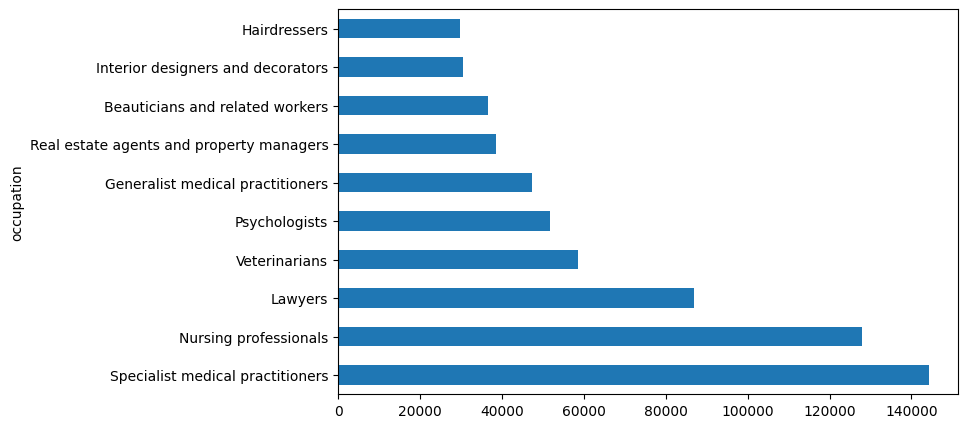

In [29]:
top10_girls.plot.barh(figsize=(8,5))

occupation
Athletes and sports players                                    102403.9913
Welders and flamecutters                                        50664.1318
Motor vehicle mechanics and repairers                           47010.0120
Software developers                                             46831.2245
Specialist medical practitioners                                36918.7153
Mechanical engineers                                            34626.2625
Lawyers                                                         33833.4008
Real estate agents and property managers                        29029.5055
Engineering professionals (excluding electrotechnology)         25675.2139
Biologists, botanists, zoologists and related professionals     24079.1862
Name: W_FSTUWT, dtype: float64

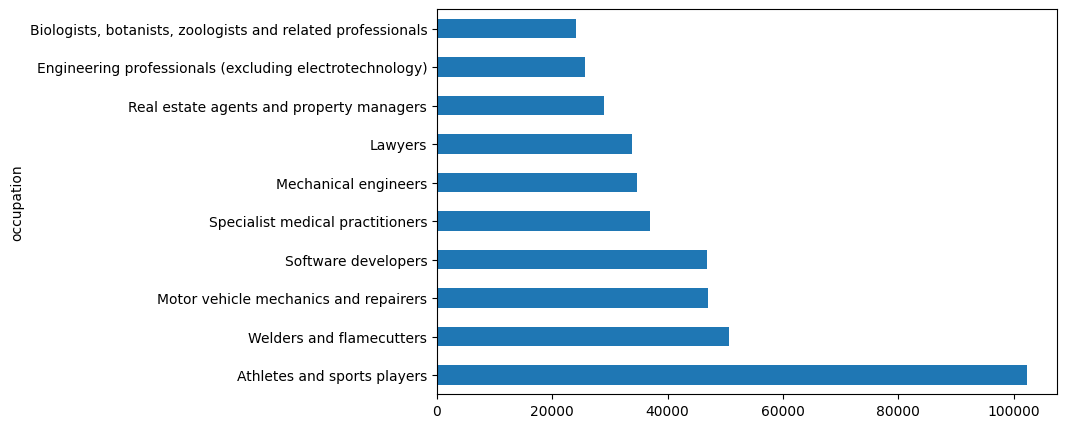

In [31]:
top10_boys.plot.barh(figsize=(8,5))
top10_boys


occupation
Early childhood educators                                      497.1649
Agricultural technicians                                       552.1778
Crop farm labourers                                            555.8112
Artistic, cultural and culinary associate professionals        555.8112
Legislators                                                    557.7143
Finance managers                                               557.7143
Administrative and commercial managers                         557.7143
Production managers in agriculture, forestry and fisheries     557.7143
Database and network professionals not elsewhere classified    578.5244
Metal, machinery and related trades workers                    611.5021
Name: W_FSTUWT, dtype: float64

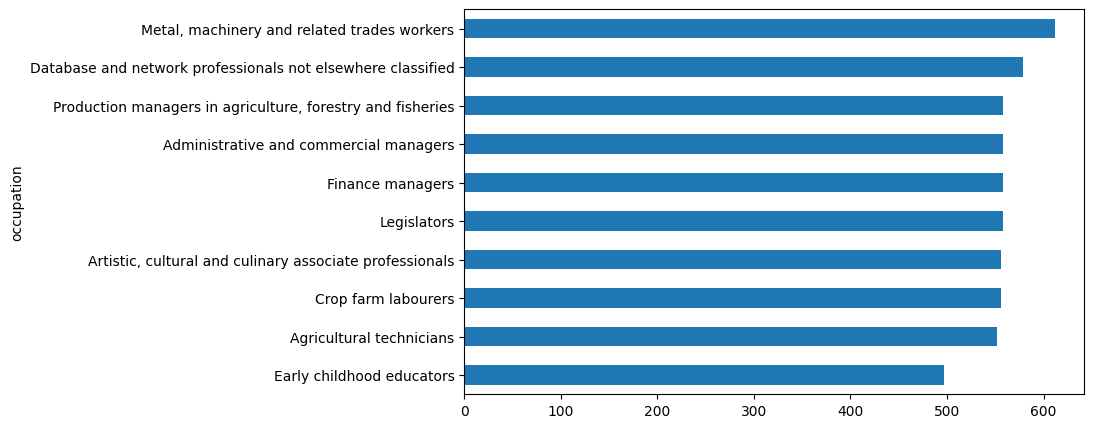

In [32]:
least10_girls=girls.groupby("occupation")["W_FSTUWT"].sum().sort_values(ascending=True).head(10)
least10_girls.plot.barh(figsize=(8,5))
least10_girls

occupation
Regulatory government associate professionals                410.2264
Mining and quarrying labourers                               410.2264
Machinery mechanics and repairers                            425.6052
Business services and administration managers                468.9852
Telecommunications engineering technicians                   485.2478
Financial and mathematical associate professionals           528.1723
Mining engineers, metallurgists and related professionals    547.4675
Chemists                                                     561.7039
Administrative and commercial managers                       578.3336
Life science professionals                                   594.5036
Name: W_FSTUWT, dtype: float64

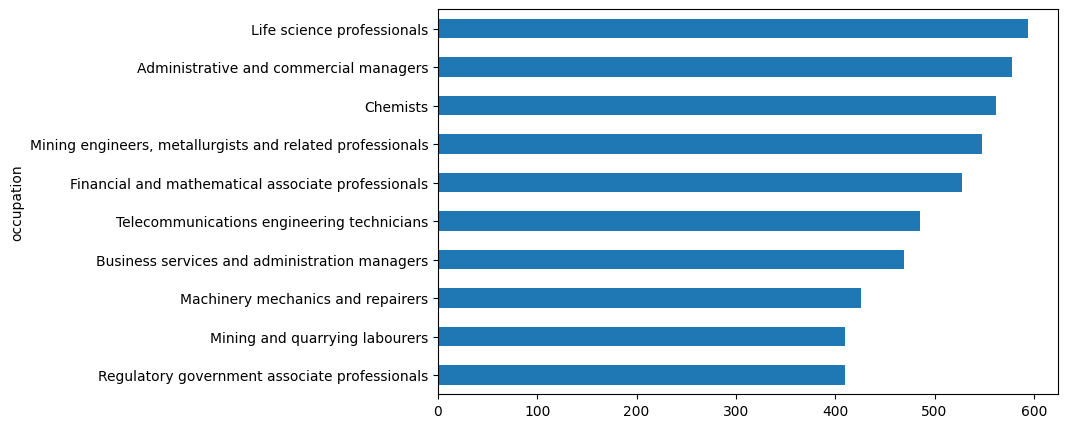

In [33]:
least10_boys=boys.groupby("occupation")["W_FSTUWT"].sum().sort_values(ascending=True).head(10)
least10_boys.plot.barh(figsize=(8,5))
least10_boys

<AxesSubplot:xlabel='occupation'>

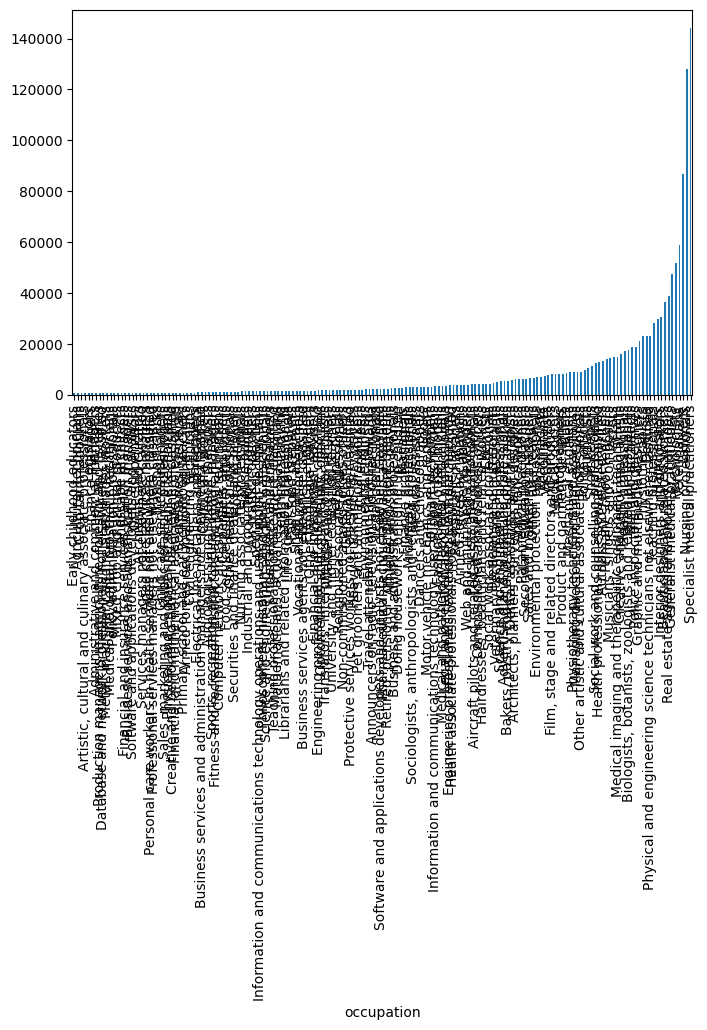

In [37]:
girls.groupby("occupation")["W_FSTUWT"].sum().sort_values(ascending=True).plot.bar(figsize=(8,5))

<AxesSubplot:xlabel='occupation'>

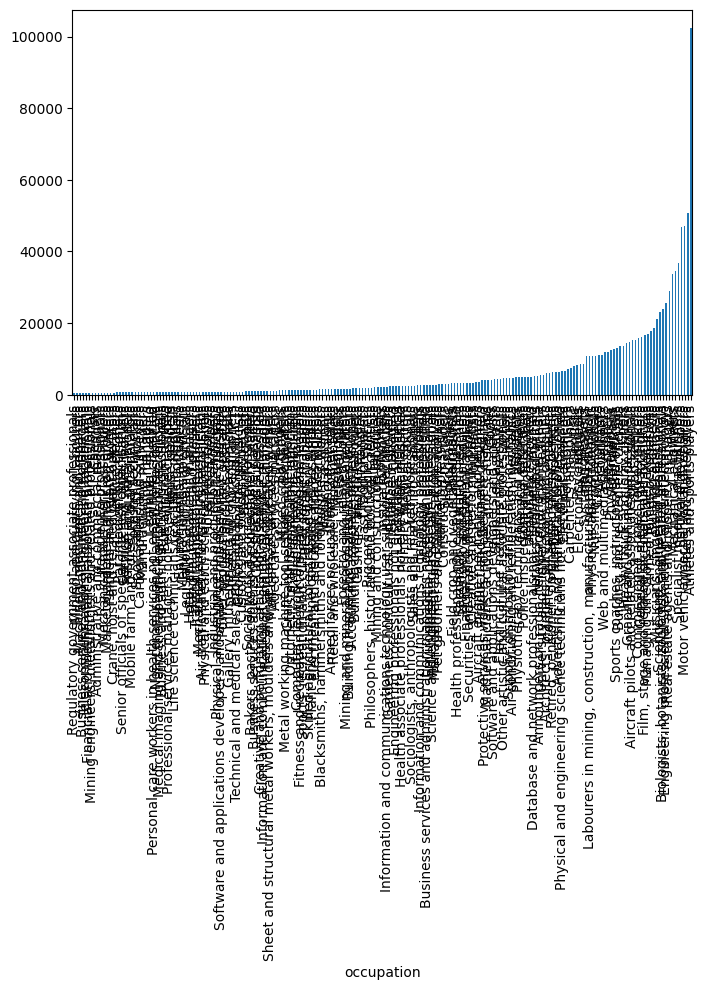

In [38]:
boys.groupby("occupation")["W_FSTUWT"].sum().sort_values(ascending=True).plot.bar(figsize=(8,5))

In [39]:
pip install yt-dlp


DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621
Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.6/171.6 kB 7.8 MB/s eta 0:00:00
  Using cached urllib3-2.2.3-py3-none-any.whl.metadata (6.5 kB)
  Using cached websockets-13.1-cp38-cp38-macosx_10_9_x86_64.whl.metadata (6.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 9.1 MB/s eta 0:00:00a 0:00:01m
Using cached urllib3-2.2.3-py3-none-any.whl (126 kB)
Using cached websockets-13.1-cp38-cp38-macosx_10_9_x86_64.whl (155 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 445.1/445.1 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.4/194.4 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.9 MB/

In [1]:
yt-dlp --write-auto-sub --sub-lang en --sub-format vtt \
       --skip-download -o "hiho" \
       "https://www.youtube.com/watch?v=RUup841pZrs"

SyntaxError: invalid syntax (3332558850.py, line 1)

In [2]:
!yt-dlp --write-auto-sub --sub-lang en --sub-format vtt --skip-download -o "hiho" "https://www.youtube.com/watch?v=RUup841pZrs"

zsh:1: command not found: yt-dlp


In [3]:
!pip install yt-dlp

DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621
Defaulting to user installation because normal site-packages is not writeable


In [4]:
!yt-dlp --write-auto-sub --sub-lang en --sub-format vtt --skip-download -o "hiho" "https://www.youtube.com/watch?v=RUup841pZrs"

zsh:1: command not found: yt-dlp


In [5]:
!python -m yt_dlp --write-auto-sub --sub-lang en --sub-format vtt --skip-download -o "hiho" "https://www.youtube.com/watch?v=RUup841pZrs"

zsh:1: command not found: python


In [6]:
yt-dlp --write-auto-sub --sub-lang en --sub-format vtt \
       --skip-download -o "hiho" \
       "https://www.youtube.com/watch?v=RUup841pZrs"

SyntaxError: invalid syntax (3332558850.py, line 1)

In [7]:
!python3 -m yt_dlp --write-auto-sub --sub-lang en --sub-format vtt --skip-download -o "hiho" "https://www.youtube.com/watch?v=RUup841pZrs"

/opt/homebrew/opt/python@3.14/bin/python3.14: No module named yt_dlp
